# Spatial Plots - Days

Contributions by Cait Roufa
Includes spatial significance testing with code from A Haberlie: https://github.com/ahaberlie/MCS_Climate/blob/main/examples/stats.py

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import os
# from copy import deepcopy
# from concurrent.futures import ProcessPoolExecutor
import warnings
# warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
import stats

In [3]:
# Suppress specific FutureWarning from xarray
warnings.filterwarnings("ignore", message=".*Index.ravel returning ndarray is deprecated.*", category=FutureWarning)

In [4]:
# modified colormaps
base_cmap = plt.cm.OrRd

# mod colormap from OrRd with 0 mapped to transparent
colors_trans = base_cmap(np.linspace(0, 1, 256))
colors_trans[0, -1] = 0  # Make the first color (lowest value, including 0) fully transparent
TrOrRd = ListedColormap(colors_trans)

# mod colormap from OrRd with 0 mapped to white
colors_white = base_cmap(np.linspace(0, 1, 256))
colors_white[0] = [1, 1, 1, 1] # white
WtOrRd = ListedColormap(colors_white)

In [5]:
# define data directory, seasons, and epoch labels
data_dir = '/home/scratch/croufa/syn_sev'
epochs = ['HIST', '4p5MID', '8p5MID', '4p5END', '8p5END']
epoch_labels = ['HIST', 'MID4.5', 'MID8.5', 'END4.5', 'END8.5']
season_months = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11]
}
seasons = list(season_months.keys())

In [6]:
# function for seasonal climatology
def seasonal_climatology(da, season):
    months = season_months[season]
    da = da.sel(Time=da['Time'].dt.month.isin(months))
    return da.sum(dim='Time')

In [7]:
# load data
ds_all = {}
for epoch in epochs:
    zarr_path = os.path.join(data_dir, f'uvv_{epoch}_combined.zarr')
    ds_all[epoch] = xr.open_zarr(zarr_path)

/home/croufa/.local/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.26.0
  warnings.warn(


In [9]:
# builds per-year arrays for sig testing

def seasonal_yearly_counts(da, months):
    """
    da: xr.DataArray with time coord 'Time' and dims (..., south_north, west_east) or (..., lat, lon)
    months: list of ints
    returns DataArray (year, y, x)
    """
    sel = da.sel(Time=da['Time'].dt.month.isin(months))
    # sum within each year
    yr = sel.groupby("Time.year").sum(dim="Time")
    # standardize dim order: (year, y, x)
    # try to detect spatial dims
    dims = dict(zip(yr.dims, yr.shape))
    # Common names in your files
    ydim = 'south_north' if 'south_north' in dims else ('lat' if 'lat' in dims else 'latitude')
    xdim = 'west_east'   if 'west_east'   in dims else ('lon' if 'lon' in dims else 'longitude')
    return yr.transpose("year", ydim, xdim)

In [10]:
# compute seasonal and annual per-year arrays for each epoch for sig testing
# seasonal per-year counts (e.g., 15 x 44 x 69)
season_years_days = {}  # keys: (epoch, season) -> (year, y, x)

for epoch in epochs:
    da = ds_all[epoch]['UVV_DAYS']  # same variable plotted later
    for season in seasons:
        months = season_months[season]
        season_years_days[(epoch, season)] = seasonal_yearly_counts(da, months)

# Annual per-year counts (sum months 1..12 by year)
annual_years_days = {}  # keys: epoch -> (year, y, x)
for epoch in epochs:
    da = ds_all[epoch]['UVV_DAYS']
    annual_years_days[epoch] = da.groupby("Time.year").sum(dim="Time").transpose(
        "year",
        'south_north' if 'south_north' in da.dims else ('lat' if 'lat' in da.dims else 'latitude'),
        'west_east'   if 'west_east'   in da.dims else ('lon' if 'lon' in da.dims else 'longitude'),
    )

In [11]:
# trying hatching instead of dots or stippling
def add_sig_hatching(ax, lons, lats, sig_mask, hatch="///", zorder=30):
    """
    ax: GeoAxes
    lons, lats: 1D or 2D; if 1D, will meshgrid
    sig_mask: 2D boolean (True where p<0.05)
    """
    if lons.ndim == 1 and lats.ndim == 1:
        LON, LAT = np.meshgrid(lons, lats)
    else:
        LON, LAT = lons, lats
    data = np.where(sig_mask, 1.0, np.nan)
    levels = [0.5, 1.5]  # two levels to confine hatching
    ax.contourf(
        LON, LAT, data, levels=levels, hatches=[hatch],
        colors="none", transform=ccrs.PlateCarree(), zorder=zorder
    )

In [27]:
# dots / stippling instead of hatching
def add_sig_stippling(ax, lons, lats, sig_mask,
                      transform=ccrs.PlateCarree(),
                      s=12, alpha=0.7, color='k', zorder=31, marker='.'):
    """
    Plot dots at grid-cell centers where sig_mask==True.
    - lons/lats: 1D or 2D arrays (if 1D, we meshgrid)
    - s: dot size (pts^2). 6–10 for dense grids; 12–16 for coarser maps
    - color: 'k' (black)
    """
    if lons.ndim == 1 and lats.ndim == 1:
        LON, LAT = np.meshgrid(lons, lats)
    else:
        LON, LAT = lons, lats

    jj, ii = np.where(sig_mask)  # row (y), col (x)
    if jj.size == 0:
        return  # nothing to draw

    ax.scatter(LON[jj, ii], LAT[jj, ii],
               s=s, c=color, alpha=alpha, marker=marker,
               linewidths=0, transform=transform, zorder=zorder)

In [12]:
# calc seasonal climatology
seasonal_maps = {}
for epoch in epochs:
    for season in seasons:
        seasonal_maps[(epoch, season)] = seasonal_climatology(ds_all[epoch]['UVV_DAYS'], season)
        
# calc seasonal climo for SCW days
seasonal_maps_days = {}
for epoch in epochs:
    for season in seasons:
        da = ds_all[epoch]['UVV_DAYS']
        months = season_months[season]
        da_season = da.sel(Time=da['Time'].dt.month.isin(months))
        seasonal_maps_days[(epoch, season)] = da_season.sum(dim='Time')

In [13]:
# annual climo
annual_maps_days = {epoch: ds_all[epoch]['UVV_DAYS'].sum(dim='Time') for epoch in epochs}

In [14]:
# annual delta and percent chg
ref_epoch = 'HIST'
future_epochs = ['4p5MID', '8p5MID', '4p5END', '8p5END']

delta_annual_days = {}
percent_annual_days = {}
for epoch in future_epochs:
    base = annual_maps_days[ref_epoch]
    future = annual_maps_days[epoch]
    delta = future - base
    percent = (delta / base.where(base > 0)) * 100
    delta_annual_days[epoch] = delta
    percent_annual_days[epoch] = percent

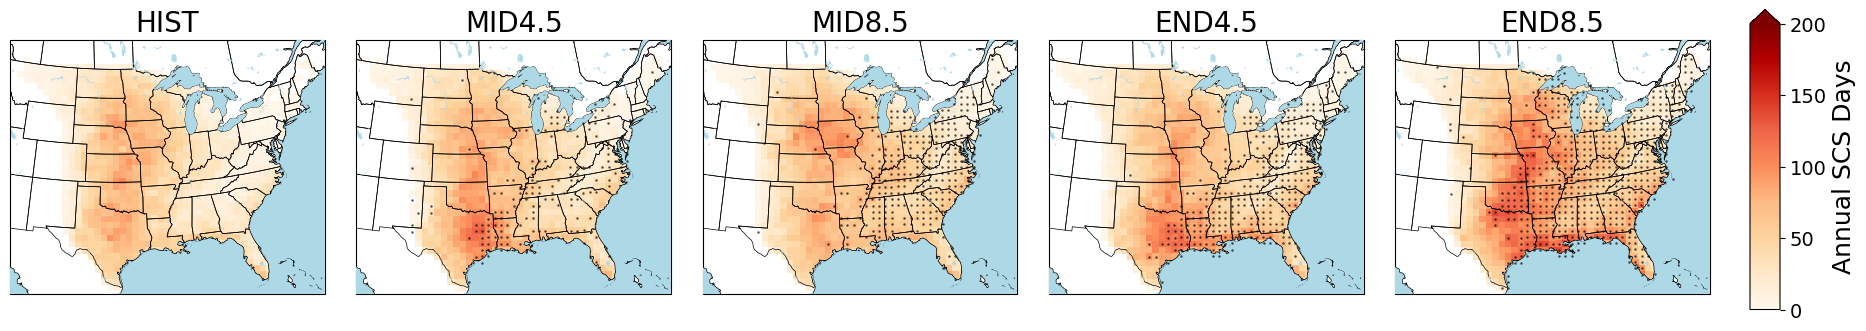

In [28]:
# plot annual climo
fig, axes = plt.subplots(
    nrows=1, ncols=len(epochs), figsize=(20, 5),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

vmin, vmax = 0, 200
for j, epoch in enumerate(epochs):
    ax = axes[j]
    da = annual_maps_days[epoch]

    mesh = ax.pcolormesh(
        da['lon'], da['lat'], da,
        transform=ccrs.PlateCarree(), cmap=WtOrRd,
        vmin=vmin, vmax=vmax
    )
    
    # build HIST vs FUT per-year arrays for the Mann–Whitney test
    hist_yrs = annual_years_days[ref_epoch].values  # (T, Y, X)
    fut_yrs  = annual_years_days[epoch].values     # (T, Y, X)
    
    # get expected dims from the arrays just built
    exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
    pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
    sig_mask = np.isfinite(pvals) & (pvals < 0.05)

    # overlay hatching
    # add_sig_hatching(ax, da['lon'].values, da['lat'].values, sig_mask, hatch="///", zorder=30)
    add_sig_stippling(ax,
                  da['lon'].values, da['lat'].values,
                  sig_mask,
                  s=12, alpha=0.7, color='k', zorder=31)

    ax.set_extent([-110, -74, 24.5, 50])
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.set_title(epoch_labels[j], fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='max')
cbar.set_label('Annual SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Annual SCW Day Climatology by Epoch', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.1)

plt.savefig('../Plots/spatial_days_annual_sig.png', format='png', dpi=500, bbox_inches='tight')

plt.show()

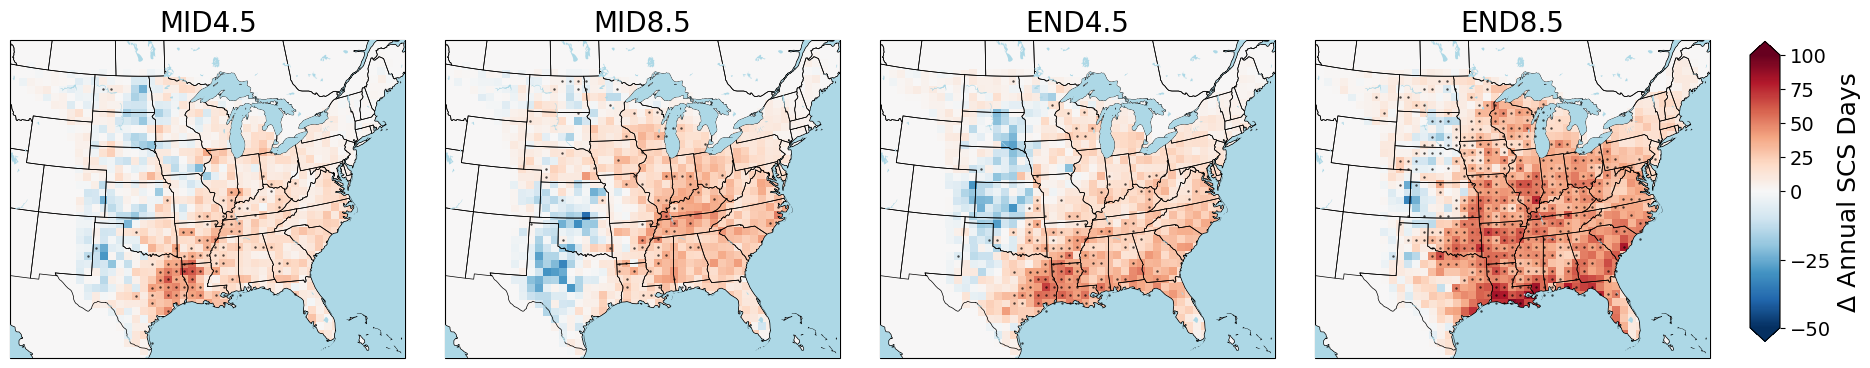

In [29]:
# plot annual delta
fig, axes = plt.subplots(
    nrows=1, ncols=len(future_epochs), figsize=(20, 5),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

norm = TwoSlopeNorm(vmin=-50, vcenter=0, vmax=100)
for j, epoch in enumerate(future_epochs):
    ax = axes[j]
    da = delta_annual_days[epoch]

    mesh = ax.pcolormesh(
        da['lon'], da['lat'], da,
        transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r, norm=norm
    )
    
    # per-year seasonal arrays for HIST and FUT
    hist_yrs = season_years_days[(ref_epoch, season)].values  # (T, Y, X)
    fut_yrs  = season_years_days[(epoch, season)].values      # (T, Y, X)

    exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
    pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
    sig_mask = np.isfinite(pvals) & (pvals < 0.05)

    # add_sig_hatching(ax, da['lon'].values, da['lat'].values, sig_mask, hatch="///", zorder=30)
    add_sig_stippling(ax,
                  da['lon'].values, da['lat'].values,
                  sig_mask,
                  s=12, alpha=0.7, color='k', zorder=31)

    ax.set_extent([-110, -74, 24.5, 50])
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.set_title(epoch_labels[j + 1], fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both')
cbar.set_label('Δ Annual SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Annual Δ SCW Days Relative to HIST', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.1)

plt.savefig('../Plots/spatial_days_annual_delta_sig.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

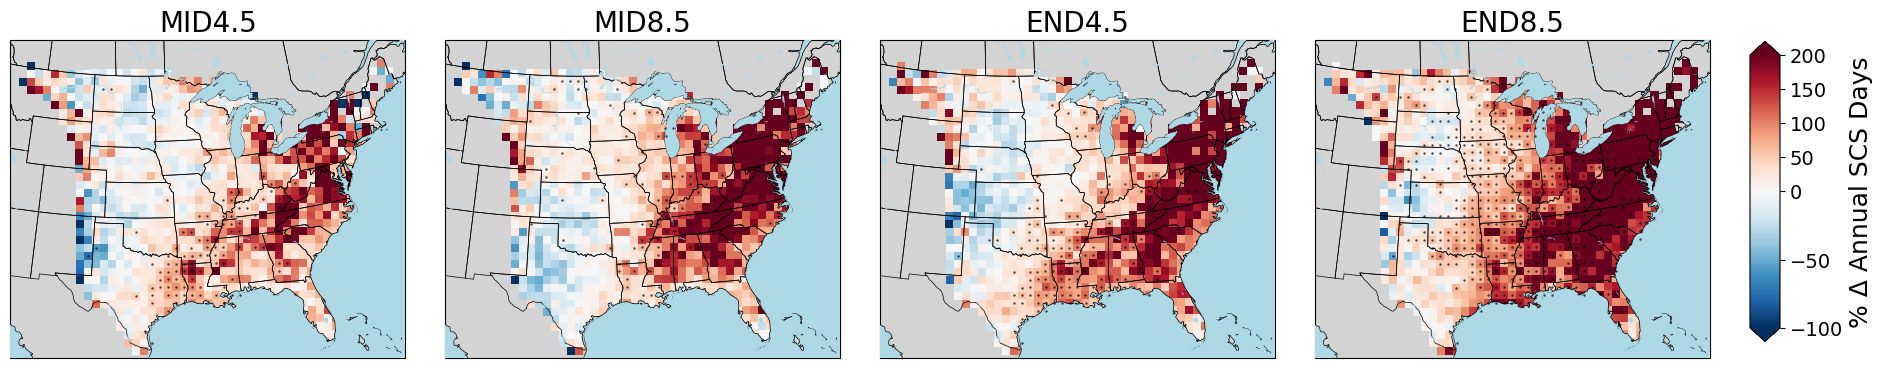

In [30]:
# plot annual percent chg
fig, axes = plt.subplots(
    nrows=1, ncols=len(future_epochs), figsize=(20, 5),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

norm_pt_ann = TwoSlopeNorm(vmin=-100, vcenter=0, vmax=200)

for j, epoch in enumerate(future_epochs):
    ax = axes[j]
    da = percent_annual_days[epoch]

    mesh = ax.pcolormesh(
        da['lon'], da['lat'], da,
        transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r, norm=norm_pt_ann
    )
    
    # per-year seasonal arrays for HIST and FUT
    hist_yrs = season_years_days[(ref_epoch, season)].values  # (T, Y, X)
    fut_yrs  = season_years_days[(epoch, season)].values      # (T, Y, X)

    exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
    pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
    sig_mask = np.isfinite(pvals) & (pvals < 0.05)

    # add_sig_hatching(ax, da['lon'].values, da['lat'].values, sig_mask, hatch="///", zorder=30)
    add_sig_stippling(ax,
                  da['lon'].values, da['lat'].values,
                  sig_mask,
                  s=12, alpha=0.7, color='k', zorder=31)

    ax.set_extent([-110, -74, 24.5, 50])
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.set_title(epoch_labels[j + 1], fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both')
cbar.set_label('% Δ Annual SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Annual % Change in SCW Days Relative to HIST', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.1)

plt.savefig('../Plots/spatial_days_annual_percent_sig.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

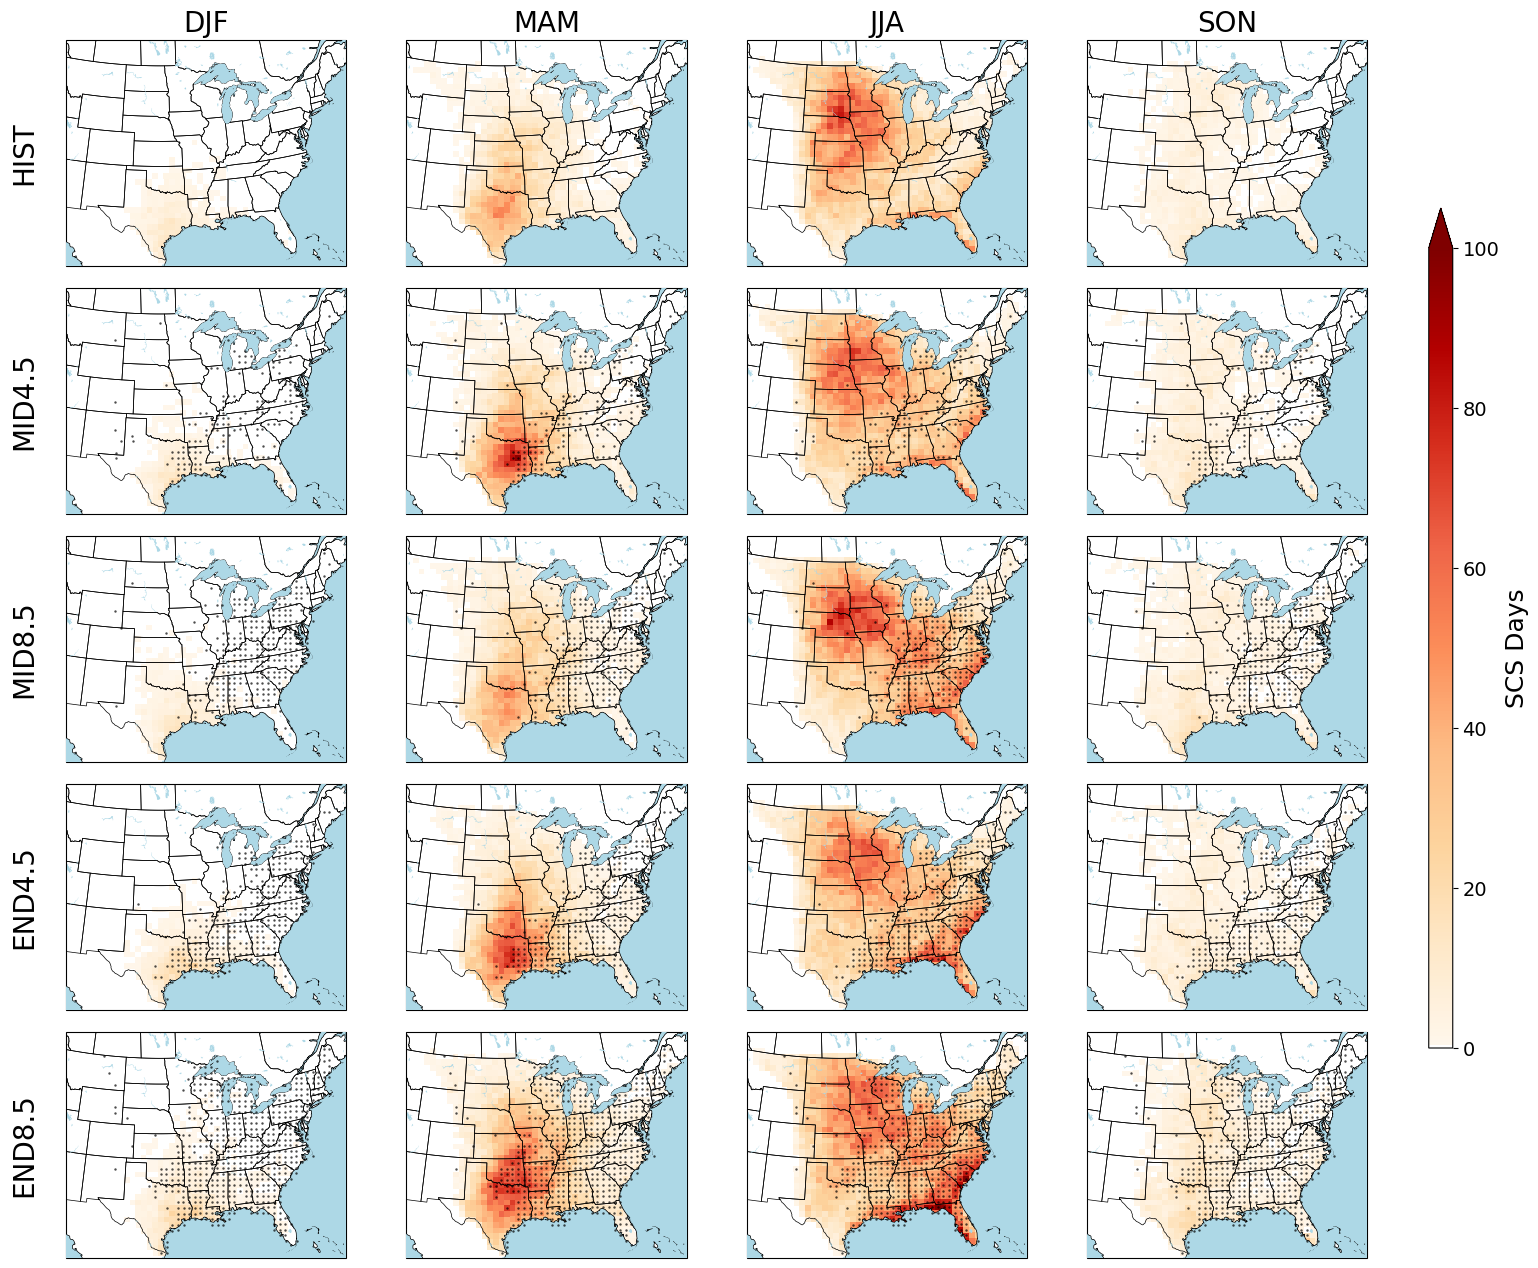

In [31]:
# plot seasonal spatial days
fig, axes = plt.subplots(
    nrows=len(epochs), ncols=len(seasons),
    figsize=(16, 14),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

vmin, vmax = 0, 100
# cmap = plt.cm.OrRd

# --- Plot each map ---
for i, epoch in enumerate(epochs):
    for j, season in enumerate(seasons):
        ax = axes[i, j]
        da = seasonal_maps[(epoch, season)]

        mesh = ax.pcolormesh(
            da['lon'], da['lat'], da,
            transform=ccrs.PlateCarree(), cmap=WtOrRd,
            vmin=vmin, vmax=vmax
        )
        
        # build HIST vs FUT per-year arrays for the Mann–Whitney test
        hist_yrs = annual_years_days[ref_epoch].values  # (T, Y, X)
        fut_yrs  = annual_years_days[epoch].values     # (T, Y, X)
    
        # get expected dims from the arrays just built
        exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
        pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
        sig_mask = np.isfinite(pvals) & (pvals < 0.05)

        # overlay hatching
        # add_sig_hatching(ax, da['lon'].values, da['lat'].values, sig_mask, hatch="///", zorder=30)
        add_sig_stippling(ax,
                  da['lon'].values, da['lat'].values,
                  sig_mask,
                  s=12, alpha=0.7, color='k', zorder=31)

        ax.set_extent([-110, -74, 24.5, 50])
        ax.add_feature(cfeature.STATES, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
        ax.add_feature(cfeature.LAKES, facecolor='lightblue')

        if i == 0:
            ax.set_title(season, fontsize=20)
        if j == 0:
            ax.text(-0.1, 0.5, epoch_labels[i], va='center', ha='right', rotation='vertical',
                    transform=ax.transAxes, fontsize=20)
            
# --- Colorbar ---
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='max')
cbar.set_label('SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('SCW Days Climatology', fontsize=18, y=0.97)
# plt.tight_layout(rect=[0, 0, 0.9, 0.95])
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.005, hspace=0.1)

plt.savefig('../Plots/spatial_days_seasonal_sig.png', format='png', dpi=500, bbox_inches='tight')

plt.show()

In [32]:
# define epochs
ref_epoch = 'HIST'
future_epochs = ['4p5MID', '8p5MID', '4p5END', '8p5END']

In [33]:
# Delta and Percent maps
delta_maps_days = {}
percent_maps_days = {}
for epoch in future_epochs:
    for season in seasons:
        base = seasonal_maps_days[(ref_epoch, season)]
        future = seasonal_maps_days[(epoch, season)]
        delta = future - base
        percent = (delta / base.where(base > 0)) * 100
        delta_maps_days[(epoch, season)] = delta
        percent_maps_days[(epoch, season)] = percent

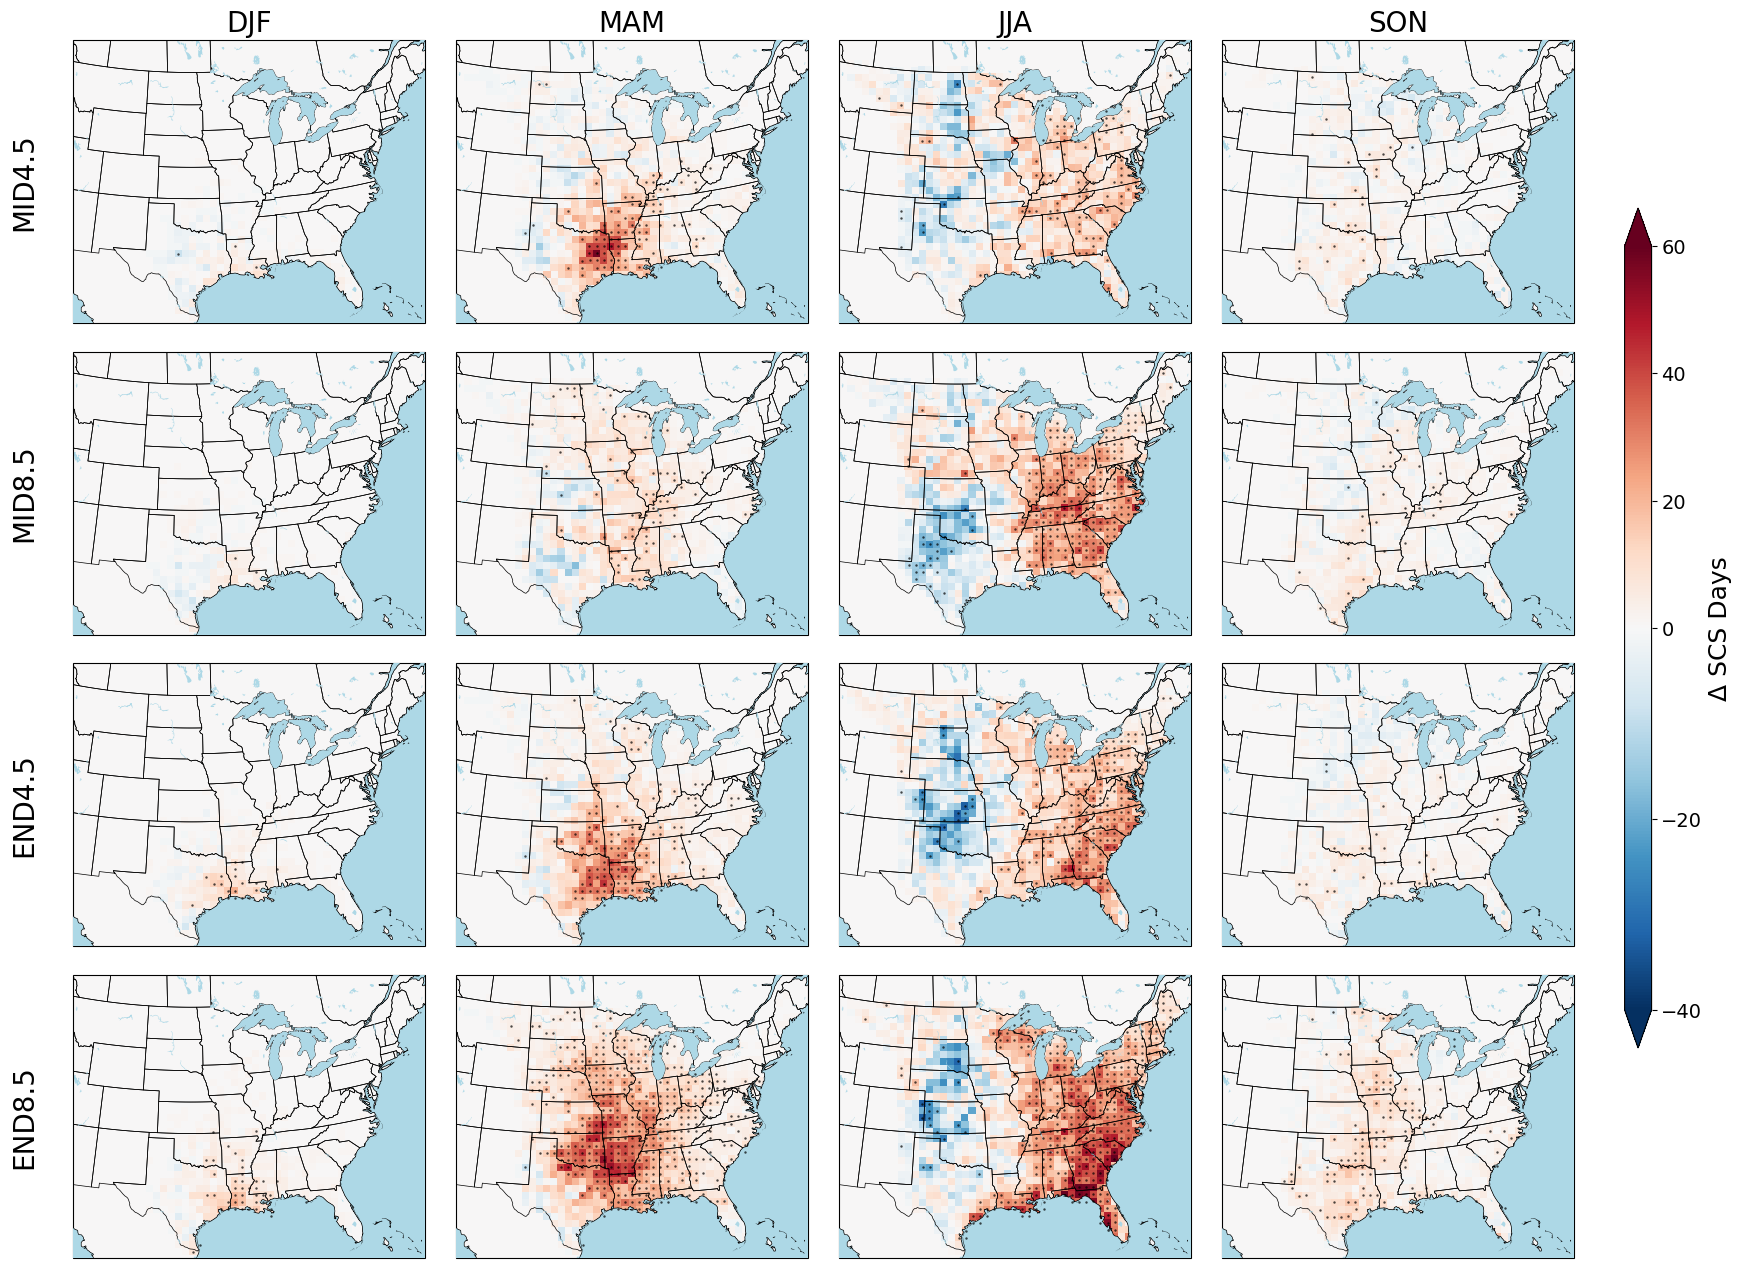

In [34]:
# plot delta days
fig, axes = plt.subplots(
    nrows=len(future_epochs), ncols=len(seasons),
    figsize=(18, 14),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

cmap_div = plt.cm.RdBu_r
# vmin, vmax = -50, 75
norm_delta = TwoSlopeNorm(vmin=-40, vcenter=0, vmax=60)

for i, epoch in enumerate(future_epochs):
    for j, season in enumerate(seasons):
        ax = axes[i, j]
        da = delta_maps_days[(epoch, season)]

        mesh = ax.pcolormesh(
            da['lon'], da['lat'], da,
            transform=ccrs.PlateCarree(), cmap=cmap_div,
            # vmin=vmin, vmax=vmax
            norm=norm_delta
        )
        
        # per-year seasonal arrays for HIST and FUT
        hist_yrs = season_years_days[(ref_epoch, season)].values  # (T, Y, X)
        fut_yrs  = season_years_days[(epoch, season)].values      # (T, Y, X)

        exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
        pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
        sig_mask = np.isfinite(pvals) & (pvals < 0.05)

        # add_sig_hatching(ax, da['lon'].values, da['lat'].values, sig_mask, hatch="///", zorder=30)
        add_sig_stippling(ax,
                  da['lon'].values, da['lat'].values,
                  sig_mask,
                  s=12, alpha=0.7, color='k', zorder=31)

        ax.set_extent([-110, -74, 24.5, 50])
        ax.add_feature(cfeature.STATES, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
        ax.add_feature(cfeature.LAKES, facecolor='lightblue')

        if i == 0:
            ax.set_title(season, fontsize=20)
        if j == 0:
            ax.text(-0.1, 0.5, epoch_labels[i+1], va='center', ha='right', rotation='vertical',
                    transform=ax.transAxes, fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both')
cbar.set_label('Δ SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Seasonal Δ SCW Days Relative to HIST', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.005, hspace=0.1)

plt.savefig('../Plots/spatial_days_seasonal_delta_sig.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

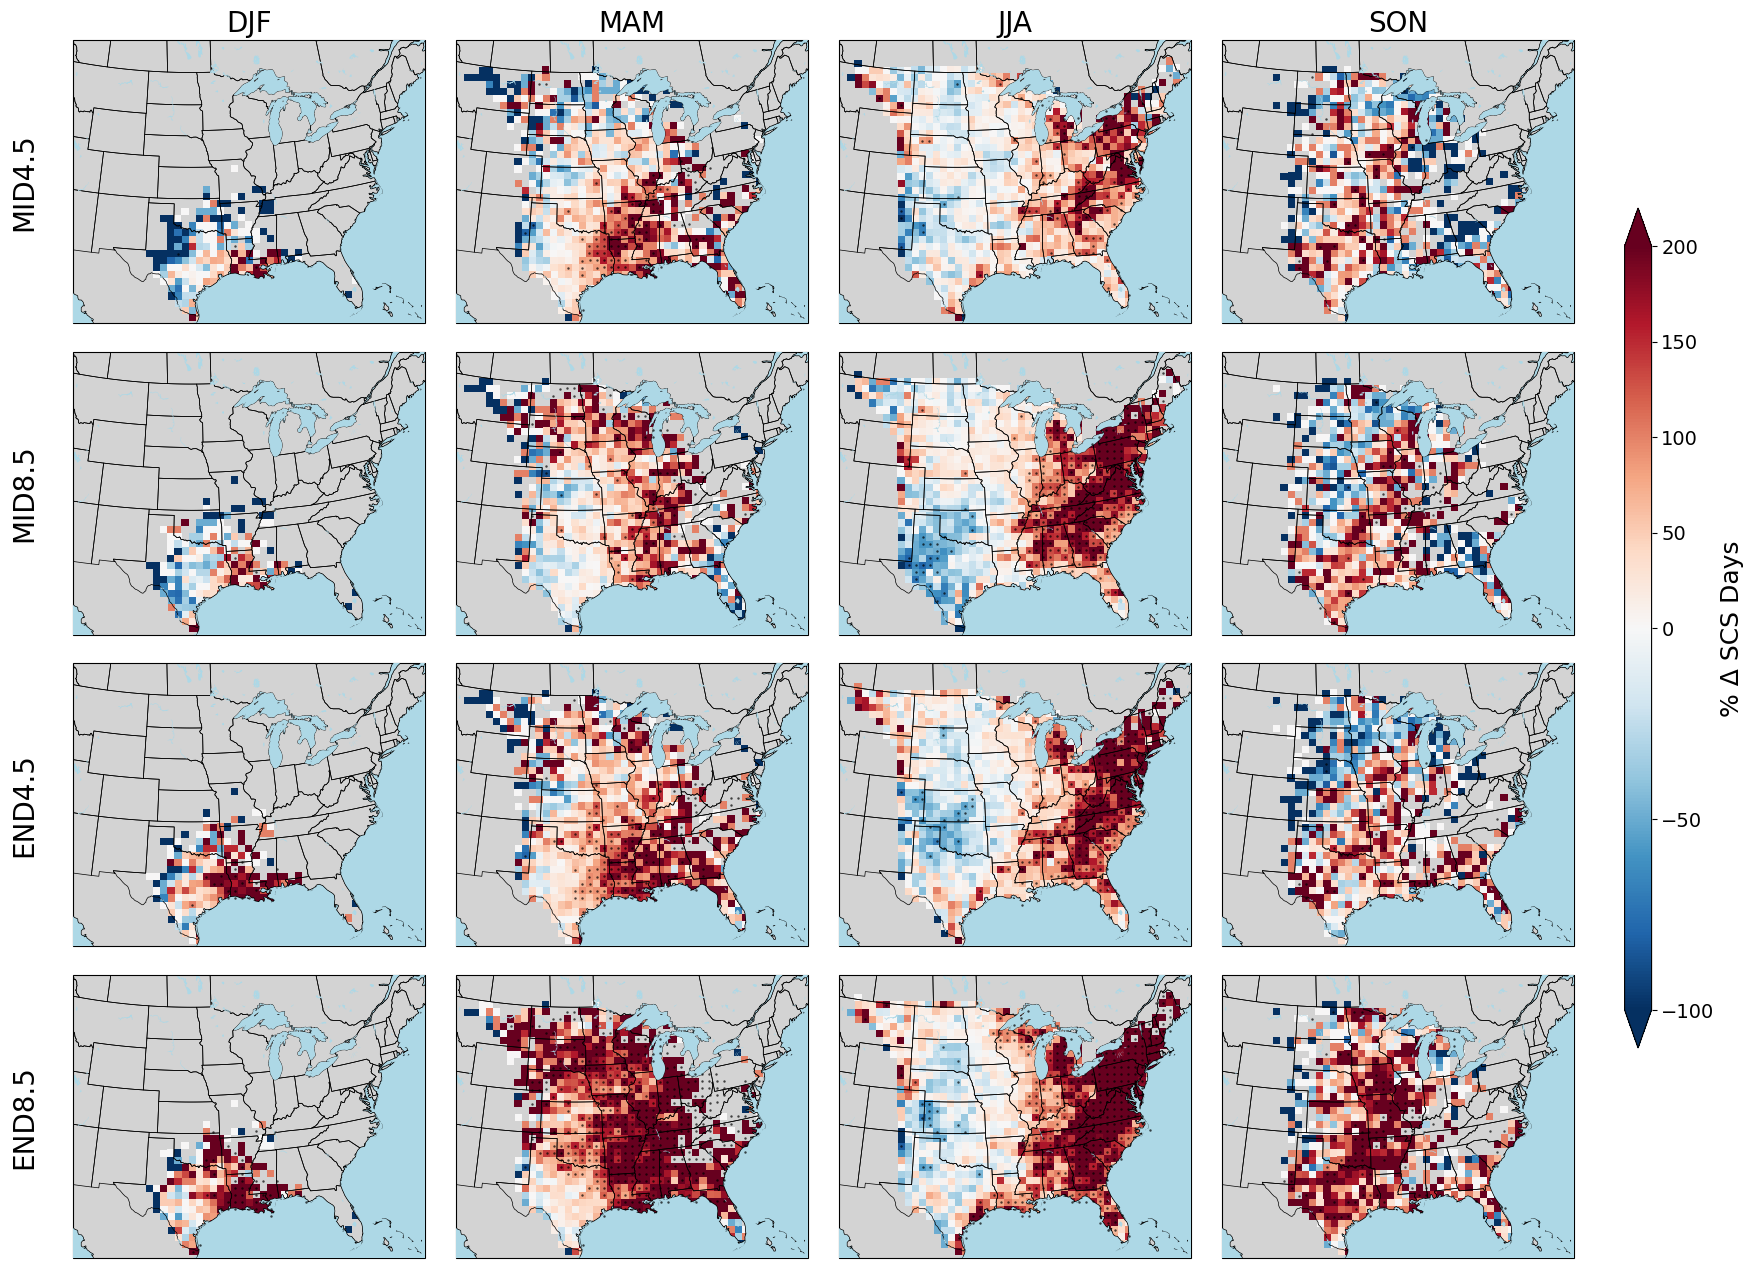

In [35]:
# plot percent chg days
fig, axes = plt.subplots(
    nrows=len(future_epochs), ncols=len(seasons),
    figsize=(18, 14),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-98, central_latitude=35)}
)

norm_percent = TwoSlopeNorm(vmin=-100, vcenter=0, vmax=200)

for i, epoch in enumerate(future_epochs):
    for j, season in enumerate(seasons):
        ax = axes[i, j]
        da = percent_maps_days[(epoch, season)]

        mesh = ax.pcolormesh(
            da['lon'], da['lat'], da,
            transform=ccrs.PlateCarree(), cmap=cmap_div,
            # vmin=vmin, vmax=vmax
            norm=norm_percent
        )
        
        # per-year seasonal arrays for HIST and FUT
        hist_yrs = season_years_days[(ref_epoch, season)].values  # (T, Y, X)
        fut_yrs  = season_years_days[(epoch, season)].values      # (T, Y, X)

        exp = (hist_yrs.shape[0], hist_yrs.shape[1], hist_yrs.shape[2])
        pvals = stats.grid_significance(hist_yrs, fut_yrs, expected_dims=exp)
        sig_mask = np.isfinite(pvals) & (pvals < 0.05)

        # add_sig_hatching(ax, da['lon'].values, da['lat'].values, sig_mask, hatch="///", zorder=30)
        add_sig_stippling(ax,
                  da['lon'].values, da['lat'].values,
                  sig_mask,
                  s=12, alpha=0.7, color='k', zorder=31)

        ax.set_extent([-110, -74, 24.5, 50])
        ax.add_feature(cfeature.STATES, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=3)
        ax.add_feature(cfeature.LAKES, facecolor='lightblue')

        if i == 0:
            ax.set_title(season, fontsize=20)
        if j == 0:
            ax.text(-0.1, 0.5, epoch_labels[i+1], va='center', ha='right', rotation='vertical',
                    transform=ax.transAxes, fontsize=20)

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both')
cbar.set_label('% Δ SCS Days', fontsize=18)
cbar.ax.tick_params(labelsize=14)

# fig.suptitle('Seasonal % Change in SCW Days Relative to HIST', fontsize=18, y=0.92)
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, wspace=0.005, hspace=0.1)

plt.savefig('../Plots/spatial_days_seasonal_percent_sig.png', format='png', dpi=500, bbox_inches='tight')
plt.show()